# Introducción a la Ciencia de Datos: Tarea 1

Este notebook contiene el código de base para realizar la Tarea 1 del curso. Puede copiarlo en su propio repositorio y trabajar sobre el mismo.
Las **instrucciones para ejecutar el notebook** están en la [página inicial del repositorio](https://gitlab.fing.edu.uy/maestria-cdaa/intro-cd).

Se utiliza el lenguaje Python y la librería Pandas. Si no tiene ninguna familiaridad con la librería, se recomienda realizar algún tutorial introductorio (ver debajo).
También se espera que los alumnos sean proactivos a la hora de consultar las documentaciones de las librerías y del lenguaje, para entender el código provisto.
Además de los recursos provistos en la [página del curso](https://eva.fing.edu.uy/course/view.php?id=1378&section=1), los siguientes recursos le pueden resultar interesantes:
 - [Pandas getting started](https://pandas.pydata.org/docs/getting_started/index.html#getting-started) y [10 minutes to pandas](https://pandas.pydata.org/docs/user_guide/10min.html): Son parte de la documentación en la página oficial de Pandas.
 - [Kaggle Learn](https://www.kaggle.com/learn): Incluye tutoriales de Python y Pandas.


Si desea utilizar el lenguaje R y está dispuesto a no utilizar (o traducir) este código de base, también puede hacerlo.

En cualquier caso, **se espera que no sea necesario revisar el código para corregir la tarea**, ya que todos los resultados y análisis relevantes deberían estar en el **informe en formato PDF**.

## Cargar bibliotecas (dependencias)
Recuerde instalar los requerimientos (`requirements.txt`) en el mismo entorno donde está ejecutando este notebook (ver [README](https://github.com/DonBraulio/introCD)).

In [2]:
from time import time
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from datasets import load_dataset

# Agregue aqui el resto de las librerias que necesite
# from ...
# import ...

## Descarga del dataset
En esta tarea se utilizará una base de datos abierta que contiene artículos de noticias publicados en distintos medios de prensa, con la finalidad de realizar una clasificación de textos según el medio de prensa al que pertenecen. [Link](https://huggingface.co/datasets/rjac/all-the-news-2-1-Component-one?utm_source=chatgpt.com) \
\
Ejecute la siguiente celda para descargar los datos y cargarlos en un dataframe de pandas. La constante `DATA_PATH` determina la ubicación donde se almacenaran los datos. \
\
El dataset entero pesa ~8.3gb. Para evitar demoras en la descarga/procesamiento vamos a utilizar el parámetro `streaming=True` y hacer un muestreo aleatorio para descargar una porción de los datos lo más representativa posible.

In [3]:
ds = load_dataset("tomas-gr/all-the-news-2-1-Component-one-sampled", streaming=True, split="train",cache_dir="../data")
df = ds.to_pandas()


DATA_PATH = "../data/all-the-news-2-1-Component-one-sampled.csv"


## Lectura de Datos

In [4]:
# Veamos las primeras filas del DataFrame
df.head()

,idx,article_idx,date,year,month,day,author,title,article,url,section,publication
0,1,1,2018-02-02,2018,2.0,2,NaN,BRIEF-Teva Says Fremanezumab Marketing Authori...,Feb 2 (Reuters) - Teva Pharmaceutical Industri...,https://www.reuters.com/article/brief-teva-say...,Healthcare,Reuters
1,2,2,2018-05-01,2018,5.0,1,NaN,CMS' Verma says it’s time health care caught u...,The head of the Centers for Medicare and Medic...,https://www.cnbc.com/2018/04/30/cms-verma-says...,Health and Science,CNBC
2,3,3,2017-08-14,2017,8.0,14,Harper Neidig,Uber investor accuses Kalanick of 'undermining...,"Benchmark, the venture capital firm that helpe...",https://thehill.com/policy/technology/346520-u...,NaN,The Hill
3,4,4,2017-04-03 00:00:00,2017,4.0,3,NaN,Chad Johnson Catches Uno Touchdown In Mexican ...,VIVA OCHOCINCO!!!!! Chad Johnson made his triu...,https://www.tmz.com/2017/04/03/chad-johnson-me...,NaN,TMZ
4,5,5,2018-12-27 19:20:08,2018,12.0,27,Aja Romano,"Hopepunk, explained: the storytelling trend th...",Literary and artistic movements often arise sp...,https://www.vox.com/2018/12/27/18137571/what-i...,NaN,Vox


In [5]:
# Veamos información general del DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30213 entries, 0 to 30212
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   idx          30213 non-null  int64
 1   article_idx  30213 non-null  int64
 2   date         30213 non-null  str  
 3   year         30213 non-null  str  
 4   month        30213 non-null  str  
 5   day          30213 non-null  str  
 6   author       18808 non-null  str  
 7   title        30213 non-null  str  
 8   article      29037 non-null  str  
 9   url          30072 non-null  str  
 10  section      19981 non-null  str  
 11  publication  30072 non-null  str  
dtypes: int64(2), str(10)
memory usage: 96.1 MB


# Parte 1: Cargado y Limpieza de Datos

## A. Exploración de Datos
Analice el contenido del DataFrame. Reporte si existen datos faltantes en algún campo, o cualquier otro problema de calidad de datos que encuentre. \
En particular, analice la cantidad de artículos por medio de prensa, y a partir de este punto trabaje con los **cinco medios con mayor cantidad de artículos**.

In [6]:
# TODO: Analice datos faltantes por columna

for columna, contenido in df.items()    :

    if contenido.isnull().sum() > 0:
        print(f"Columna {columna} tiene {df[columna].isnull().sum()} valores nulos")


nulos = df.isnull().sum()
print(f"\nColumnas con valores nulos:\n{nulos[nulos > 0]}")


Columna author tiene 11405 valores nulos
Columna article tiene 1176 valores nulos
Columna url tiene 141 valores nulos
Columna section tiene 10232 valores nulos
Columna publication tiene 141 valores nulos

Columnas con valores nulos:
author         11405
article         1176
url              141
section        10232
publication      141
dtype: int64


In [7]:
# TODO: Analice la cantidad de artículos por medio de prensa

# Tome los 5 medios con más artículos
publications = df['publication'].value_counts()

# print(f"Las publications por medio son: {publications}")

top_5_publications = publications.head(5)
print(f"\nLas 5 publicaciones con más artículos son:\n{top_5_publications}")
# 
df_top_5 = df[df['publication'].isin(top_5_publications.index)]




Las 5 publicaciones con más artículos son:
publication
Reuters               9431
The New York Times    2840
CNBC                  2623
The Hill              2349
People                1528
Name: count, dtype: int64


## B. Visualización temporal
Genere una gráfica que permita visualizar los artículos de los cinco medios a lo largo del tiempo, con alguna escala temporal adecuada. \
Comente si se identifican momentos de mayor actividad o patrones temporales en la cobertura.

Text(0.5, 0, 'Fecha')

<Figure size 1200x800 with 0 Axes>

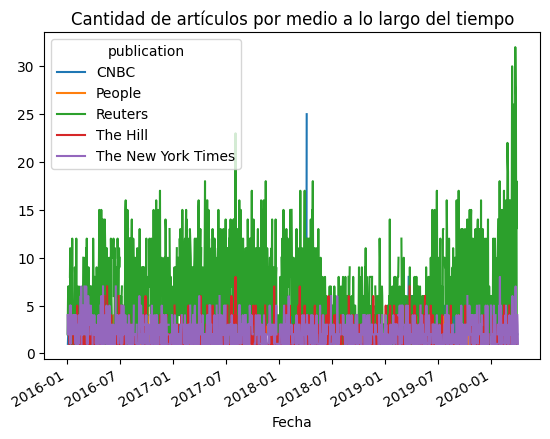

<Figure size 1200x800 with 0 Axes>

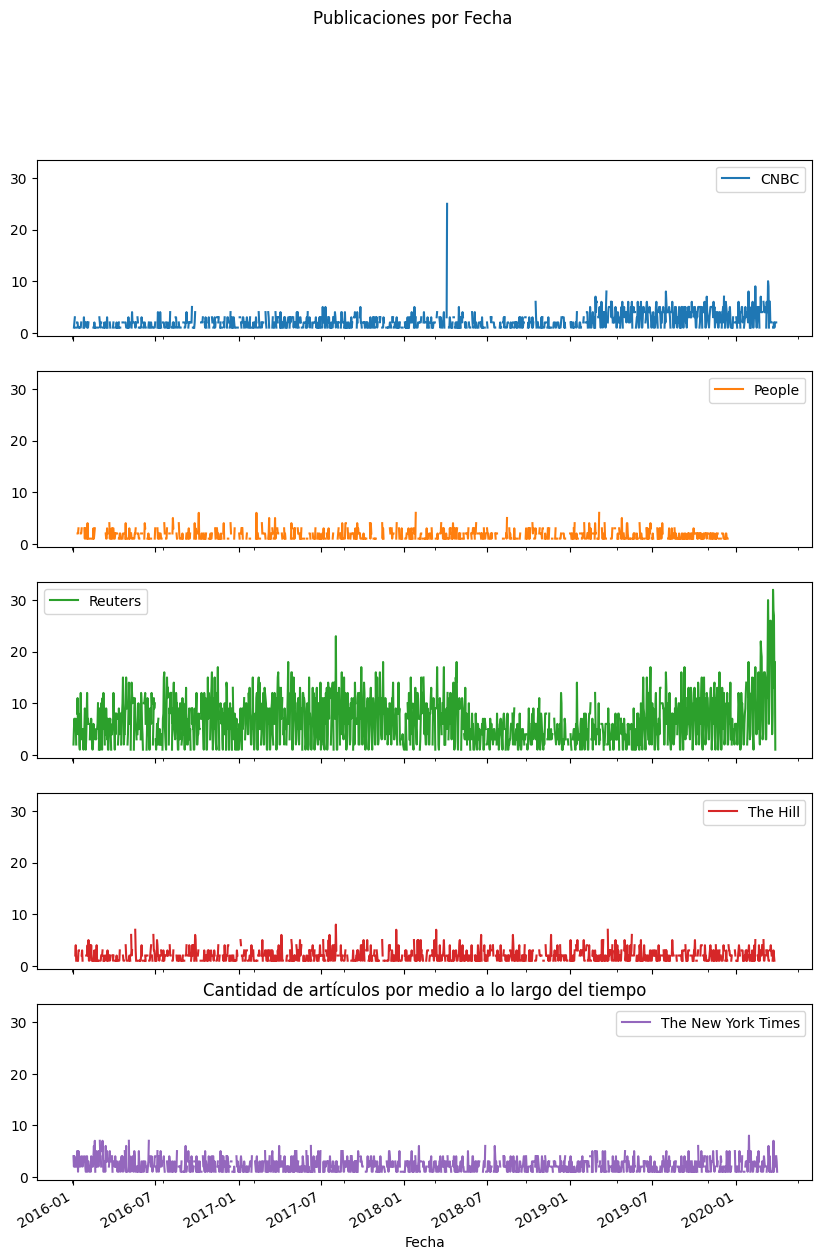

In [8]:
# TODO: Visualización de los artículos de cada medio a lo largo del tiempo
# Preste especial atención al formato de la columna 'date', ya que puede contener diferentes formatos de fecha.
# Esto modifica 'df' añadiendo la columna 'fecha'
df_top_5['fecha'] = pd.to_datetime(df_top_5[['year', 'month', 'day']])

plot_df = df_top_5.groupby(['fecha', 'publication']).size().unstack()

# Graficar la cantidad de artículos por medio a lo largo del tiempo
plt.figure(figsize=(12, 8))
plot_df.plot()
plt.title('Cantidad de artículos por medio a lo largo del tiempo')
plt.xlabel('Fecha')

# Reuters desde Julio 2018 a Julio 2019 tuvo un descenso significativo en la cantidad de publicaciones
# CNBC desde 2019 incremento la cantidad de publicaciones
# People, the Hill y New York Times no tuvieron cambios significativos en la cantidad de publicaciones


# Graficar la cantidad de artículos por medio a lo largo del tiempo
plt.figure(figsize=(12, 8))
plot_df.plot(subplots=True, figsize=(10, 15), sharex=True, sharey=True, title="Publicaciones por Fecha")
plt.title('Cantidad de artículos por medio a lo largo del tiempo')
plt.xlabel('Fecha')

## C. Limpieza de texto y conteo de palabras
Se provee la función `clean_text(...)` que realiza parte de la normalización del texto. \
**Complete la función** agregando signos de puntuación faltantes y cualquier otra normalización que considere oportuna. \
Compruebe el resultado observando el contenido del DataFrame procesado. Comente todas las transformaciones que haya agregado y justifique.

In [ ]:
def clean_text(df, column_name):

    # Eliminar primeras palabras hasta el primer "\n"
    result = df[column_name].str.replace(r"^[^\n]*\n", "", regex=True)

    # Convertir todo a minúsculas
    result = result.str.lower()

    # TODO: completar signos de puntuación faltantes
    for punc in ["[", "]", "\n", ",",".","!","?","(",")","-","_","*","'","\"","/","\\","#","$","%","&","^","~","`","|","{","}","\t","\r","\f","\v", ""]:
        result = result.str.replace(punc, " ")

    return result

In [10]:
# TODO: Aplique clean_text sobre la columna de texto elegida y cree una nueva columna "CleanText"
df_top_5['Cleantext'] = clean_text(df_top_5, 'article')
df_top_5['CleanTitle'] = clean_text(df_top_5, 'title')


## D. Elección de campos de texto
Discuta si conviene trabajar con:
- sólo el cuerpo del artículo,
- sólo el título,
- o una combinación de ambos.

Justifique brevemente su decisión.

Conviene usar Clea_Text tanto en el titulo como en el contenido del articulo. Ambos tienen en su version original muchos simbolos de puntuacion que pueden dificultar su procesamiento posterior y no agregan valor en el analisis. 

*TODO: Escriba su análisis en el informe.*

## E. Pistas que identifican al medio de prensa
Analice si en el texto aparecen pistas que identifiquen de manera directa al medio de prensa (nombres del medio, URLs, firmas, nombres de secciones, plantillas repetidas, etc.). \
En caso de encontrarlas, comente si considera conveniente eliminarlas o reducir su impacto, y justifique su decisión.

In [26]:
# TODO: Explore el texto buscando pistas que identifiquen directamente al medio de prensa
# Por ejemplo, busque nombres de medios, URLs, firmas, etc.

# Función para extraer el fragmento donde aparece el medio
def extraer_fragmento(texto, termino, ventana=50):
    texto = str(texto)
    indice = texto.lower().find(termino.lower())
    if indice != -1:
        inicio = max(0, indice - ventana)
        fin = min(len(texto), indice + len(termino) + ventana)
        return f"...{texto[inicio:fin]}..."
    return "No aparece el nombre del medio en el artículo."

for medio in df_top_5['publication'].unique():
    print(f"\nEjemplos de artículos de {medio} donde se menciona al medio en el artículo:\n")
    
    articulos_filtrados = df_top_5[df_top_5['publication'] == medio]['Cleantext'].head(5)
    
    for article_idx, texto in articulos_filtrados.items():
        fragmento = extraer_fragmento(texto, medio)
        # Imprime el ID real del DataFrame y el fragmento
        print(f"{article_idx}: {fragmento}")

for medio in df_top_5['publication'].unique():
    print(f"\nEjemplos de artículos de {medio} donde se menciona al medio en la URL:\n")
    art_filtrados = df_top_5[df_top_5['publication'] == medio]['url'].head(5)

    for article_idx, url in art_filtrados.items():
        fragmento = extraer_fragmento(url, medio)
        print(f"{article_idx}: {fragmento}")



Ejemplos de artículos de Reuters donde se menciona al medio en el artículo:

0: ...feb 2  reuters    teva pharmaceutical industries ltd :   europea...
6: ...toronto  dec 4  reuters    bank of montreal on tuesday reported a 19 perc...
15: ...houston  reuters    an outage on a major pipeline from the largest...
18: ... stockholm london  reuters    u s  scientists jeffrey hall  michael rosbash ...
20: No aparece el nombre del medio en el artículo.

Ejemplos de artículos de CNBC donde se menciona al medio en el artículo:

1: No aparece el nombre del medio en el artículo.
5: No aparece el nombre del medio en el artículo.
12: ...takeholders in recapitalizing the banks   he told cnbc on the sidelines of the ambrosetti forum in italy...
40: No aparece el nombre del medio en el artículo.
49: ...es when it came to the former u s  oilman  follow cnbc international on and facebook ...

Ejemplos de artículos de The Hill donde se menciona al medio en el artículo:

2: ...en asked for comment  view t

## F. Restricción por sección o período temporal
Evalúe si conviene restringir el análisis a artículos de una misma sección temática o de un período temporal acotado, con el objetivo de reducir el efecto del tema sobre una futura tarea de clasificación por medio. \
No es necesario implementar esta restricción, pero sí discutir sus posibles ventajas y desventajas.

*TODO: Escriba su análisis en el informe.*

# Parte 2: Conteo de Palabras y Visualizaciones

## A. Palabras más frecuentes por medio
Realice una visualización que permita comparar las palabras más frecuentes de cada uno de los cinco medios de prensa. \
Sin necesidad de implementarlo, proponga ideas para modificar esta visualización con el fin de encontrar diferencias entre secciones temáticas, fechas, o tipos de noticias.

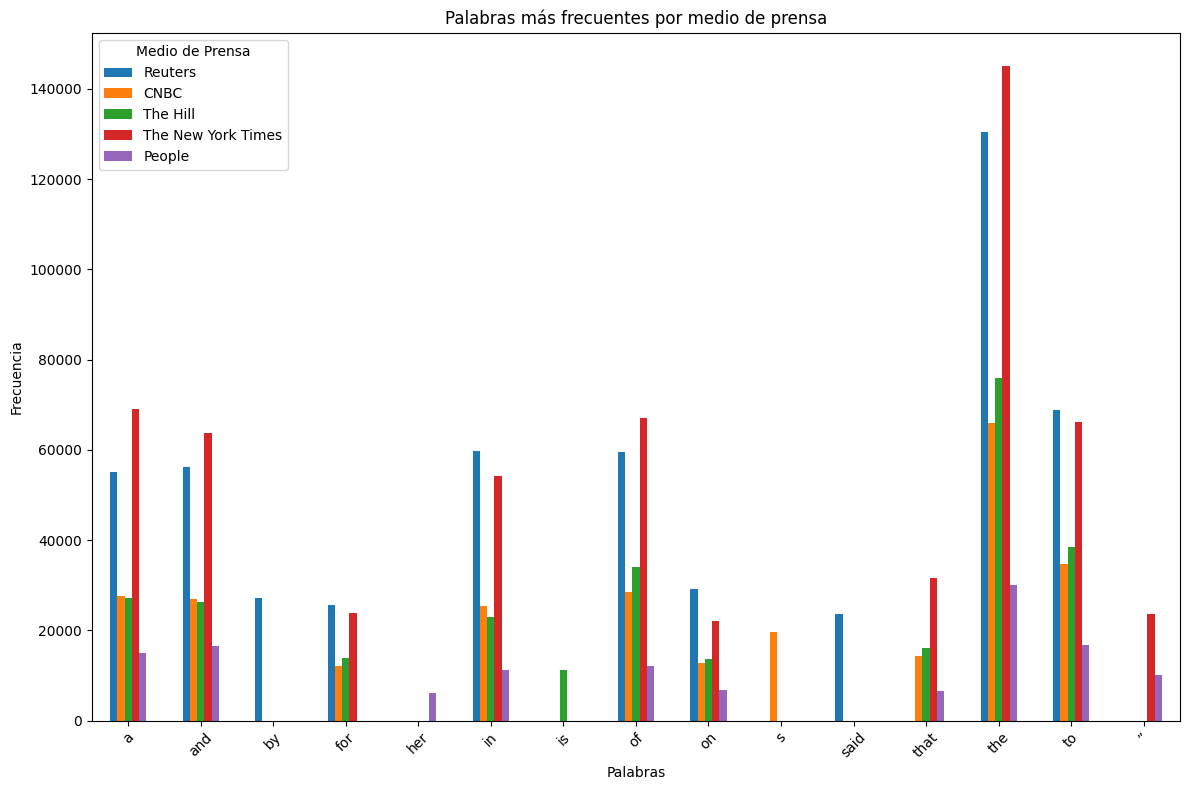

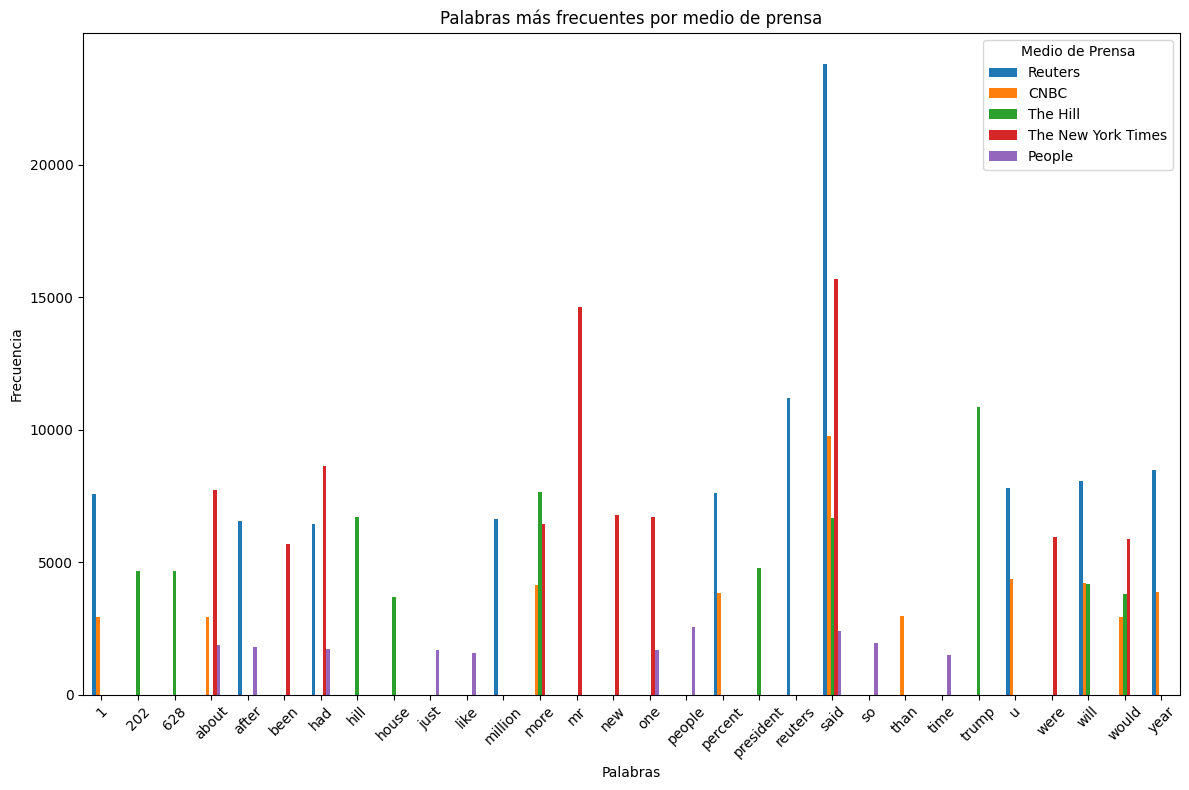

In [35]:
# TODO: Realice una visualización que permita comparar las palabras más frecuentes
# de cada uno de los cinco medios de prensa.
# - ¿Encuentra algún problema en los resultados?

word_freq = {}
for medio in df_top_5['publication'].unique():
    # Filtramos nulos, convertimos a string y unimos
    columna_limpia = df_top_5[df_top_5['publication'] == medio]['Cleantext'].dropna().astype(str)
    texto_completo = " ".join(columna_limpia)
    palabras = texto_completo.split()
    frecuencia = pd.Series(palabras).value_counts().head(10)
    word_freq[medio] = frecuencia

# Convertir el diccionario en un DataFrame para facilitar la visualización
df_word_freq = pd.DataFrame(word_freq).fillna(0)
df_word_freq.plot(kind='bar', figsize=(12, 8))
plt.title('Palabras más frecuentes por medio de prensa')
plt.xlabel('Palabras')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.legend(title='Medio de Prensa')
plt.tight_layout()
plt.show()

#se ve el problema de que las palabras más frecuentes son muy genéricas y no aportan información relevante sobre el medio de prensa. Esto puede deberse a que los artículos contienen muchas palabras comunes que no son distintivas de cada medio. Para mejorar esto, se podría considerar eliminar stop words o enfocarse en palabras clave específicas relacionadas con cada medio.

def clean_text_stopwords(df, column_name):
    
    result = df[column_name].astype(str).str.lower()
    result = result.str.replace(r'[^\w\s]', ' ', regex=True)
    stopwords = ["i","s", "t", "up", "down","in", "out", "the", "and", "is", "in", "to", "of", "a", "that", "it", "with", "as", "for", "was", "on", "are", "by", "this", "be", "from", "at", "or", "an", "which", "not", "all", "have", "has", "but", "they", "their", "its", "if", "we", "he", "she", "my", "me", "you", "his", "her", "them", "what", "who", "when", "where", "why", "how", "the", "and", "is", "in", "to", "of", "a", "that", "it", "with", "as", "for", "was", "on", "are", "by", "this", "be", "from", "at", "or", "an", "which", "not", "all", "have", "has", "but", "they", "their", "its", "if", "we", "he", "she", "my", "me", "you", "his", "her", "them"]
    
    for stopword in stopwords:     
        result = result.str.replace(rf"\b{stopword}\b", " ", regex=True)
    return result

df_top_5['Cleantext_Stopwords'] = clean_text_stopwords(df_top_5, 'Cleantext')

word_freq = {}
for medio in df_top_5['publication'].unique():
    # Filtramos nulos, convertimos a string y unimos
    columna_limpia = df_top_5[df_top_5['publication'] == medio]['Cleantext_Stopwords'].dropna().astype(str)
    texto_completo = " ".join(columna_limpia)
    palabras = texto_completo.split()
    frecuencia = pd.Series(palabras).value_counts().head(10)
    word_freq[medio] = frecuencia

# Convertir el diccionario en un DataFrame para facilitar la visualización
df_word_freq = pd.DataFrame(word_freq).fillna(0)
df_word_freq.plot(kind='bar', figsize=(12, 8))
plt.title('Palabras más frecuentes por medio de prensa')
plt.xlabel('Palabras')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.legend(title='Medio de Prensa')
plt.tight_layout()
plt.show()

## B. Medios con mayor cantidad de palabras
Corra el código que permite encontrar los medios con mayor cantidad de palabras. \
En caso de encontrar algún problema luego de realizar la visualización, comente a qué se debe y proponga formas de resolverlo.

In [39]:
# TODO: Busque los medios con mayor cantidad de palabras

word_count = df_top_5.groupby('publication')['Cleantext_Stopwords'].apply(lambda x: x.str.split().str.len().sum())

print(f"\nCantidad total de palabras por medio:\n{word_count.sort_values(ascending=False)}")


Cantidad total de palabras por medio:
publication
Reuters               1780158.0
The New York Times    1661083.0
The Hill               934412.0
CNBC                   822477.0
People                 398161.0
Name: Cleantext_Stopwords, dtype: float64


## C. Matriz de menciones entre medios
Construya una matriz de 5×5, donde cada fila y columna corresponden a un medio de prensa, y la entrada (i,j) contiene la cantidad de veces que el medio *i* menciona al medio *j*. \
\
**Opcional:** genere un grafo dirigido con esa matriz de adyacencia para visualizar las menciones. Puede ser útil la biblioteca `networkx`.

In [48]:
# TODO: Construya una matriz de 5x5, donde cada fila y columna corresponden a un medio de prensa,
# y la entrada (i,j) contiene la cantidad de veces que el medio "i" menciona al medio "j".

# 1. Aseguramos que los nombres de los medios estén limpios y en minúsculas para la búsqueda
medios = df_top_5['publication'].unique()
mentions_matrix = pd.DataFrame(0, index=medios, columns=medios)

# 2. Iteramos por cada medio de origen (filas)
for medio_origen in medios:
    # Obtenemos todos los textos de ese medio en una serie
    textos_del_medio = df_top_5[df_top_5['publication'] == medio_origen]['Cleantext'].astype(str).str.lower()
    
    # 3. Iteramos por cada medio objetivo (columnas)
    for medio_objetivo in medios:
        # Usamos una búsqueda simple de strings sobre toda la serie de textos
        # Esto cuenta cuántas veces aparece el nombre del 'medio_objetivo' 
        # en los artículos del 'medio_origen'
        nombre_buscar = medio_objetivo.lower()
        
        # Contamos cuántos artículos contienen el nombre del medio objetivo
        conteo = textos_del_medio.str.contains(rf'\b{nombre_buscar}\b', regex=True).sum()
        
        # 4. Asignamos el valor exacto a la celda
        mentions_matrix.loc[medio_origen, medio_objetivo] = conteo

print("\nMatriz de menciones:\n")
print(mentions_matrix)


Matriz de menciones:

                    Reuters  CNBC  The Hill  The New York Times  People
Reuters                8358    31         2                  29    1506
CNBC                    821   899         5                  46     811
The Hill                 71    13      2335                 127     959
The New York Times       45    13        15                 482    1590
People                    4     3         4                  38    1018


In [15]:
# Opcional: Genere un grafo dirigido con la matriz de adyacencia para visualizar las menciones.
# Puede ser útil la biblioteca networkx.



## D. Preguntas propuestas
Proponga al menos tres preguntas que se podrían intentar responder a partir de estos datos, y mencione posibles caminos para responderlas, sin implementar nada.

*TODO: Escriba sus preguntas y posibles caminos en el informe.*